# Неделя 6 — объединение разных представлений двигателя через OOF stacking

## 1. Идея недели

На шестой неделе лучшим результатом стала модель Льва, объединяющая aggregated RandomForest, квантильный прогноз и out-of-fold residual correction. Она достигла MAE примерно 8.79 на official test.

При этом в проекте существует другая содержательная ветка: модель Дениса с нормализацией относительно начального состояния двигателя и health-oriented признаками. Она уступает модели Льва по MAE, но показывает более консервативное поведение и меньшую склонность к завышению остаточного ресурса.

Эти модели используют разные представления данных:
- модель Льва сильнее оптимизирована по общей точности;
- модель Дениса оценивает отклонение двигателя от собственного начального состояния.

Если их ошибки различаются, объединение прогнозов может быть полезнее любой отдельной модели. Поэтому на этой неделе мы проверяем OOF stacking: обучаем маленький второй уровень только на out-of-fold прогнозах внутри train-выборки, а official test используем только для финальной оценки.

## 2. Imports and configuration

In [12]:
import os
import json
import time
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from IPython.display import Markdown, display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

N_FOLDS = 5
USE_RAW_WINDOW_BRANCH = False

CURRENT_BEST_MAE = 8.79
CURRENT_BEST_METHOD_NAME = "Week 6 Lev OOF residual correction"

META_CORRECTION_CLIPS = [3, 5, 7, 10]
validation_target_ruls = [10, 20, 30, 50, 70, 90, 110, 130]
alpha_grid = np.arange(0.0, 1.01, 0.05)

DATA_DIR = Path("CMAPSSData")

LEV_CAP = 140
LEV_Q = 0.35
LEV_Q_WEIGHT = 0.6
LEV_MEAN_WEIGHT = 0.4
LEV_SHIFT = 1.0

DENIS_BASELINE_CYCLES = 20
DENIS_WINDOW_SIZE = 50
DENIS_RUL_CAP = 125
DENIS_SHIFT = 0.5
DENIS_RF_PARAMS = dict(n_estimators=400, max_depth=20, min_samples_leaf=3, min_samples_split=5, max_features=None, random_state=RANDOM_STATE, n_jobs=-1)

final_rf_base = {"n_estimators": 400, "random_state": RANDOM_STATE, "n_jobs": -1}

columns = [
    "unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3",
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20", "sensor_21",
]

target_col = "Remaining Useful Life"
eps = 1e-6
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)

In [13]:
def none_if_missing(value):
    if value is None:
        return None
    if isinstance(value, str) and value in {"None", "nan", "NaN", ""}:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return value


def parse_rf_max_features(value):
    value = none_if_missing(value)
    if value is None:
        return None
    if isinstance(value, str):
        if value in {"sqrt", "log2"}:
            return value
        try:
            return float(value)
        except ValueError:
            return value
    return value


best_week4_candidate = {
    "selected_blocks": [
        "delta", "edge_means", "first", "last_minus_mean", "max", "mean", "median", "min",
        "range", "slope", "slope_change", "std", "tail_quantiles", "volatility",
    ],
    "window_size": 40,
    "rul_cap": 125,
    "rf_max_depth": 24,
    "rf_min_samples_leaf": 3,
    "rf_min_samples_split": 2,
    "rf_max_features": 0.4,
}
old_week4_shift = 2.0
pd.DataFrame([{**best_week4_candidate, "lev_cap": LEV_CAP, "lev_shift": LEV_SHIFT, "denis_shift": DENIS_SHIFT}])

,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,lev_cap,lev_shift,denis_shift
0,"[delta, edge_means, first, last_minus_mean, ma...",40,125,24,3,2,0.4,140,1.0,0.5


## 3. Загрузка данных

Используем NASA C-MAPSS FD001. Для train считаем RUL как разницу между последним циклом двигателя и текущим циклом. Для official test используем последнюю доступную историю каждого test unit и true RUL из `RUL_FD001.txt`.

In [14]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_table(data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns)
    test_df = pd.read_table(data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns)
    rul_test_df = pd.read_table(data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    return train_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_source_cols = [col for col in train_df.columns if col.startswith("op_setting_") or col.startswith("sensor_")]

pd.DataFrame({"dataset": ["train", "test", "official_rul"], "rows": [len(train_df), len(test_df), len(rul_test_df)], "units": [train_df["unit_id"].nunique(), test_df["unit_id"].nunique(), len(rul_test_df)]})

,dataset,rows,units
0,train,20631,100
1,test,13096,100
2,official_rul,100,100


## 4. Метрики оценки

MAE остаётся основной метрикой точности, но asymmetric RUL score и overestimation-метрики нужны для safety-оценки. Завышение остаточного ресурса опаснее занижения, поскольку может привести к слишком позднему обслуживанию двигателя.

In [15]:
def asymmetric_rul_score(y_true, y_pred):
    errors = np.asarray(y_pred) - np.asarray(y_true)
    scores = np.where(errors < 0, np.exp(-errors / 13.0) - 1.0, np.exp(errors / 10.0) - 1.0)
    return float(np.sum(scores))


def asymmetric_score_parts(y_true, y_pred):
    errors = np.asarray(y_pred) - np.asarray(y_true)
    scores = np.where(errors < 0, np.exp(-errors / 13.0) - 1.0, np.exp(errors / 10.0) - 1.0)
    over_mask = errors >= 0
    under_mask = errors < 0
    return {
        "asymmetric_RUL_score": float(np.sum(scores)),
        "mean_asymmetric_score": float(np.mean(scores)),
        "overestimation_component": float(np.sum(scores[over_mask])) if np.any(over_mask) else 0.0,
        "underestimation_component": float(np.sum(scores[under_mask])) if np.any(under_mask) else 0.0,
    }


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_df = pd.DataFrame({"model_name": model_name, "id": ids, "true_rul": np.asarray(y_true), "pred_rul": np.asarray(y_pred)})
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_subset_extended(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    if zone == "mid_life":
        return error_df[(error_df["true_rul"] > 70) & (error_df["true_rul"] <= 120)]
    if zone == "long_rul":
        return error_df[error_df["true_rul"] > 120]
    return error_df


def metrics_from_error_extended(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset_extended(error_df, "near_failure")
    warning = zone_subset_extended(error_df, "warning_zone")
    metrics = {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_count": int((error_df["error"] > 0).sum()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "mean_overestimation": float(over.mean()) if len(over) else 0.0,
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": mean_absolute_error(near["true_rul"], near["pred_rul"]) if len(near) else np.nan,
        "warning_zone_MAE": mean_absolute_error(warning["true_rul"], warning["pred_rul"]) if len(warning) else np.nan,
    }
    metrics.update(asymmetric_score_parts(error_df["true_rul"], error_df["pred_rul"]))
    return metrics


def evaluate_prediction(method, y_true, y_pred, ids=None, selection_basis="", extra=None):
    row = {"method": method, "selection_basis": selection_basis}
    row.update(metrics_from_error_extended(build_error_table(y_true, y_pred, method, ids)))
    if extra:
        row.update(extra)
    return row


metric_columns = ["MAE", "RMSE", "R2", "asymmetric_RUL_score", "mean_error", "overestimation_share", "mean_overestimation", "max_overestimation", "near_failure_MAE", "warning_zone_MAE"]

## 5. Воспроизведение лучшего baseline Льва

Ветка Льва использует лучший aggregated RandomForest pipeline, cap=140, квантильную формулу Week 5 и OOF residual correction из Week 6.

In [16]:
all_feature_blocks = [
    "mean", "std", "min", "max", "range", "delta", "slope", "last_minus_mean",
    "median", "iqr", "first", "last", "relative_delta", "relative_last_minus_mean",
    "rms", "edge_means", "slope_change", "tail_quantiles", "robust_spread", "volatility",
]


def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x ** 2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"


def expected_feature_columns(config):
    suffixes_by_block = {"edge_means": ["first_edge", "last_edge"], "tail_quantiles": ["q10", "q90"]}
    result = []
    for block_name in config["selected_blocks"]:
        for suffix in suffixes_by_block.get(block_name, ["value"]):
            for source_col in feature_source_cols:
                result.append(feature_name(source_col, block_name, suffix, config["window_size"]))
    return result


def make_block_frame(block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [feature_name(col, block_name, suffix, window_size) for col in frame.columns]
            frames.append(frame)
        return pd.concat(frames, axis=1)
    frame = block_values.copy()
    frame.columns = [feature_name(col, block_name, "value", window_size) for col in frame.columns]
    return frame


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(window=window_size, min_periods=min_periods)
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(window=edge_window_size, min_periods=edge_min_periods)
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(window_size - 1)
    if not require_full_window:
        first_features = first_features.fillna(sorted_df.groupby("unit_id")[feature_source_cols].transform("first"))
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features, "std": std_features, "min": min_features, "max": max_features,
        "range": max_features - min_features, "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(level=0, drop=True),
        "last_minus_mean": last_minus_mean_features, "median": median_features,
        "iqr": q75_features - q25_features, "first": first_features, "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + eps),
        "relative_last_minus_mean": last_minus_mean_features / (mean_features.abs() + eps),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {
            "first_edge": rolling.apply(lambda values: np.mean(values[:edge_window_size]), raw=True).reset_index(level=0, drop=True),
            "last_edge": edge_rolling.mean().reset_index(level=0, drop=True),
        },
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(level=0, drop=True),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(level=0, drop=True),
    }
    return pd.concat([make_block_frame(block, block_values[block], window_size) for block in config["selected_blocks"]], axis=1)

In [17]:
def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("Пустая история cutoff")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)], "std": [("value", float(np.std(values)))],
            "min": [("value", min_value)], "max": [("value", max_value)],
            "range": [("value", max_value - min_value)], "delta": [("value", last_value - first_value)],
            "slope": [("value", calculate_slope(values))], "last_minus_mean": [("value", last_value - mean_value)],
            "median": [("value", float(np.median(values)))], "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)], "last": [("value", last_value)],
            "relative_delta": [("value", (last_value - first_value) / (abs(first_value) + eps))],
            "relative_last_minus_mean": [("value", (last_value - mean_value) / (abs(mean_value) + eps))],
            "rms": [("value", calculate_rms(values))],
            "edge_means": [("first_edge", float(np.mean(values[:edge_window_size]))), ("last_edge", float(np.mean(values[-edge_window_size:])))],
            "slope_change": [("value", calculate_slope_change(values))],
            "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)], "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in config["selected_blocks"]:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    return row


def build_aggregated_features_for_units(df, config, mode, validation_cutoffs=None, cap_target=True):
    expected_columns = expected_feature_columns(config)
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(sorted_df, config, require_full_window=True)
        result_df = pd.concat([sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1)
        result_df = result_df[result_df["cycle"] >= config["window_size"]].dropna().reset_index(drop=True)
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if cap_target and config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(sorted_df, config, require_full_window=False)
        result_df = pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1).dropna().reset_index(drop=True)
        last_rows = result_df.sort_values(["unit_id", "cycle"]).groupby("unit_id").tail(1).sort_values("unit_id").reset_index(drop=True)
        return last_rows[expected_columns], last_rows["unit_id"].reset_index(drop=True)
    if mode == "validation_cutoff":
        grouped = {unit_id: unit_df.sort_values("cycle") for unit_id, unit_df in df.groupby("unit_id")}
        rows = []
        y_values = []
        ids = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            raise ValueError("Validation-признаки содержат NaN")
        return X, pd.Series(y_values), pd.Series(ids)
    raise ValueError(f"Unknown mode: {mode}")

In [18]:
def build_rf_params(candidate, base):
    params = base.copy()
    params.update({
        "max_depth": candidate["rf_max_depth"],
        "min_samples_leaf": candidate["rf_min_samples_leaf"],
        "min_samples_split": candidate["rf_min_samples_split"],
        "max_features": candidate["rf_max_features"],
    })
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_df = pd.DataFrame({"model_name": model_name, "id": ids, "true_rul": np.asarray(y_true), "pred_rul": np.asarray(y_pred)})
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_subset(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    return error_df


def compute_week4_fitness(metrics):
    near_mae = metrics["near_failure_MAE"] if not pd.isna(metrics["near_failure_MAE"]) else metrics["MAE"]
    warning_mae = metrics["warning_zone_MAE"] if not pd.isna(metrics["warning_zone_MAE"]) else metrics["MAE"]
    return metrics["MAE"] + 4.0 * metrics["overestimation_share"] + 0.08 * near_mae + 0.04 * warning_mae + 0.03 * metrics["max_overestimation"]


def metrics_from_error(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset(error_df, "near_failure")
    warning = zone_subset(error_df, "warning_zone")
    metrics = {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": mean_absolute_error(near["true_rul"], near["pred_rul"]) if len(near) else np.nan,
        "warning_zone_MAE": mean_absolute_error(warning["true_rul"], warning["pred_rul"]) if len(warning) else np.nan,
    }
    metrics["fitness"] = compute_week4_fitness(metrics)
    return metrics


def metrics_row(model_name, prediction_type, y_true, y_pred, ids=None, extra=None):
    error_df = build_error_table(y_true, y_pred, model_name, ids)
    row = {"model_name": model_name, "prediction_type": prediction_type, **metrics_from_error(error_df)}
    if extra:
        row.update(extra)
    return row, error_df


def safety_summary(error_df):
    return pd.DataFrame({
        "zone": ["near_failure", "warning_zone", "all"],
        "count": [len(zone_subset(error_df, "near_failure")), len(zone_subset(error_df, "warning_zone")), len(error_df)],
        "MAE": [metrics_from_error(zone_subset(error_df, "near_failure"))["MAE"] if len(zone_subset(error_df, "near_failure")) else np.nan, metrics_from_error(zone_subset(error_df, "warning_zone"))["MAE"] if len(zone_subset(error_df, "warning_zone")) else np.nan, metrics_from_error(error_df)["MAE"]],
        "overestimation_share": [float((zone_subset(error_df, "near_failure")["error"] > 0).mean()) if len(zone_subset(error_df, "near_failure")) else np.nan, float((zone_subset(error_df, "warning_zone")["error"] > 0).mean()) if len(zone_subset(error_df, "warning_zone")) else np.nan, float((error_df["error"] > 0).mean())],
    })


def rul_zone_analysis(error_df):
    bins = [-1, 30, 70, 125, np.inf]
    labels = ["0-30", "31-70", "71-125", "126+"]
    zoned = error_df.copy()
    zoned["rul_zone"] = pd.cut(zoned["true_rul"], bins=bins, labels=labels)
    rows = []
    for zone, group in zoned.groupby("rul_zone", observed=False):
        if len(group):
            rows.append({"rul_zone": str(zone), "count": len(group), **metrics_from_error(group)})
    return pd.DataFrame(rows)

In [19]:
def lev_tree_summary(tree_predictions):
    lev_mean_prediction = tree_predictions.mean(axis=0)
    lev_q20 = np.quantile(tree_predictions, 0.20, axis=0)
    lev_q35 = np.quantile(tree_predictions, LEV_Q, axis=0)
    lev_q50 = np.quantile(tree_predictions, 0.50, axis=0)
    lev_q80 = np.quantile(tree_predictions, 0.80, axis=0)
    lev_tree_std = tree_predictions.std(axis=0)
    lev_tree_iqr = lev_q80 - lev_q20
    lev_base_before_residual = np.maximum(LEV_Q_WEIGHT * lev_q35 + LEV_MEAN_WEIGHT * lev_mean_prediction - LEV_SHIFT, 0)
    return pd.DataFrame({
        "lev_mean_prediction": lev_mean_prediction,
        "lev_q20": lev_q20,
        "lev_q35": lev_q35,
        "lev_q50": lev_q50,
        "lev_q80": lev_q80,
        "lev_tree_std": lev_tree_std,
        "lev_tree_iqr": lev_tree_iqr,
        "lev_base_before_residual": lev_base_before_residual,
    })


def lev_calibration_features(summary_df):
    result = summary_df[["lev_base_before_residual", "lev_mean_prediction", "lev_q20", "lev_q35", "lev_q50", "lev_q80", "lev_tree_std", "lev_tree_iqr"]].copy()
    result["lev_mean_minus_q35"] = result["lev_mean_prediction"] - result["lev_q35"]
    result["lev_q80_minus_q35"] = result["lev_q80"] - result["lev_q35"]
    result["lev_q35_minus_q20"] = result["lev_q35"] - result["lev_q20"]
    result["lev_predicted_near_flag"] = (result["lev_base_before_residual"] <= 30).astype(int)
    result["lev_predicted_warning_flag"] = ((result["lev_base_before_residual"] > 30) & (result["lev_base_before_residual"] <= 70)).astype(int)
    result["lev_predicted_long_flag"] = (result["lev_base_before_residual"] > 120).astype(int)
    return result


def make_target_rul_cutoffs(valid_df, target_ruls, window_size):
    rows = []
    for unit_id, unit_df in valid_df.groupby("unit_id"):
        max_cycle = int(unit_df["cycle"].max())
        for target_rul in target_ruls:
            cutoff_cycle = max_cycle - int(target_rul)
            if cutoff_cycle > 0 and cutoff_cycle >= window_size:
                rows.append({"unit_id": unit_id, "cutoff_cycle": cutoff_cycle, "true_rul": int(target_rul)})
    return pd.DataFrame(rows).drop_duplicates(["unit_id", "cutoff_cycle"]).reset_index(drop=True)


def train_lev_model(train_part_df):
    candidate = best_week4_candidate.copy()
    candidate["rul_cap"] = LEV_CAP
    X_train, y_train_raw = build_aggregated_features_for_units(train_part_df, candidate, "train", cap_target=False)
    y_train = y_train_raw.clip(upper=LEV_CAP)
    model = RandomForestRegressor(**build_rf_params(candidate, final_rf_base))
    model.fit(X_train, y_train)
    return model, candidate, X_train.shape[1]


def predict_lev_official(model, candidate, test_part_df):
    X_test, unit_ids = build_aggregated_features_for_units(test_part_df, candidate, "official_test")
    tree_predictions = np.array([tree.predict(X_test) for tree in model.estimators_])
    summary = lev_tree_summary(tree_predictions)
    return summary, unit_ids, X_test.shape[1]


def predict_lev_cutoffs(model, candidate, valid_part_df, cutoffs_df):
    X_valid, y_valid, valid_ids = build_aggregated_features_for_units(valid_part_df, candidate, "validation_cutoff", validation_cutoffs=cutoffs_df, cap_target=False)
    tree_predictions = np.array([tree.predict(X_valid) for tree in model.estimators_])
    summary = lev_tree_summary(tree_predictions)
    return summary, y_valid.reset_index(drop=True), valid_ids.reset_index(drop=True), X_valid.shape[1]


def lev_correction_model_factories():
    return {
        "Lev_RF_depth4": lambda: RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=5, min_samples_split=10, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
        "Lev_RF_depth6": lambda: RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=4, min_samples_split=8, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
        "Lev_GB_huber": lambda: GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.03, loss="huber", random_state=RANDOM_STATE),
    }

## 6. Воспроизведение лучшей ветки Дениса

Ветка Дениса использует baseline normalization относительно первых 20 циклов двигателя, delta-сенсоры, `health_coeff`, baseline std/range и rolling RandomForest с capped RUL.

In [20]:
sensor_cols = [c for c in columns if c.startswith("sensor_")]
op_cols = [c for c in columns if c.startswith("op_setting_")]
denis_feature_source_cols = op_cols + sensor_cols


def compute_denis_engine_baselines(df, n_cycles=DENIS_BASELINE_CYCLES):
    first = df[df["cycle"] <= n_cycles]
    records = []
    for unit_id, group in first.groupby("unit_id"):
        row = {"unit_id": unit_id}
        for col in sensor_cols:
            values = group[col].values
            row[f"{col}_baseline_mean"] = float(np.mean(values))
            row[f"{col}_baseline_std"] = float(np.std(values, ddof=0))
            row[f"{col}_baseline_range"] = float(np.max(values) - np.min(values))
        records.append(row)
    return pd.DataFrame(records).set_index("unit_id")


def compute_denis_health_coeff(baselines_df):
    std_cols = [f"{c}_baseline_std" for c in sensor_cols]
    range_cols = [f"{c}_baseline_range" for c in sensor_cols]
    std_mat = baselines_df[std_cols].values.astype(float)
    range_mat = baselines_df[range_cols].values.astype(float)
    std_norm = std_mat / (std_mat.max(axis=0) + eps)
    range_norm = range_mat / (range_mat.max(axis=0) + eps)
    instability = (std_norm.mean(axis=1) + range_norm.mean(axis=1)) / 2.0
    return pd.Series(1.0 - instability, index=baselines_df.index, name="health_coeff")


def apply_denis_baseline_transform(df, baselines_df, health_series):
    result = df.copy()
    for col in sensor_cols:
        result[col] = result[col] - result["unit_id"].map(baselines_df[f"{col}_baseline_mean"])
    for col in sensor_cols:
        result[f"{col}_baseline_std"] = result["unit_id"].map(baselines_df[f"{col}_baseline_std"])
        result[f"{col}_baseline_range"] = result["unit_id"].map(baselines_df[f"{col}_baseline_range"])
    result["health_coeff"] = result["unit_id"].map(health_series)
    result["baseline_deviation_summary"] = result[sensor_cols].abs().mean(axis=1)
    return result


def prepare_denis_dataframe(df):
    baselines = compute_denis_engine_baselines(df)
    health = compute_denis_health_coeff(baselines)
    transformed = apply_denis_baseline_transform(df, baselines, health)
    return transformed, baselines, health


def build_denis_rolling_features(df, window_size=DENIS_WINDOW_SIZE, min_periods=1):
    sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    roll_cols = denis_feature_source_cols
    edge_w = max(1, min(10, window_size // 3))
    rolling = sorted_df.groupby("unit_id")[roll_cols].rolling(window=window_size, min_periods=min_periods)
    edge_rolling = sorted_df.groupby("unit_id")[roll_cols].rolling(window=edge_w, min_periods=1)
    mean_f = rolling.mean().reset_index(level=0, drop=True)
    std_f = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_f = rolling.min().reset_index(level=0, drop=True)
    max_f = rolling.max().reset_index(level=0, drop=True)
    median_f = rolling.median().reset_index(level=0, drop=True)
    q25_f = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_f = rolling.quantile(0.75).reset_index(level=0, drop=True)
    last_f = sorted_df[roll_cols]
    first_f = sorted_df.groupby("unit_id")[roll_cols].shift(window_size - 1).fillna(sorted_df.groupby("unit_id")[roll_cols].transform("first"))
    edge_last_f = edge_rolling.mean().reset_index(level=0, drop=True)
    def rename(frame, suffix):
        renamed = frame.copy()
        renamed.columns = [f"{c}_{suffix}_{window_size}" for c in renamed.columns]
        return renamed
    feature_df = pd.concat([
        rename(mean_f, "mean"), rename(std_f, "std"), rename(min_f, "min"), rename(max_f, "max"), rename(max_f - min_f, "range"),
        rename(last_f - first_f, "delta"), rename(rolling.apply(calculate_slope, raw=True).reset_index(level=0, drop=True), "slope"),
        rename(last_f - mean_f, "last_minus_mean"), rename(median_f, "median"), rename(q75_f - q25_f, "iqr"),
        rename(rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True), "rms"),
        rename(rolling.apply(calculate_slope_change, raw=True).reset_index(level=0, drop=True), "slope_change"),
        rename(first_f, "first"), rename(last_f, "last"), rename(edge_last_f, "last_edge"),
    ], axis=1)
    static_names = ["health_coeff", "baseline_deviation_summary"] + [f"{c}_baseline_std" for c in sensor_cols] + [f"{c}_baseline_range" for c in sensor_cols]
    for name in static_names:
        feature_df[name] = sorted_df[name].values
    columns_to_keep = ["unit_id", "cycle"] + ([target_col] if target_col in sorted_df.columns else [])
    return pd.concat([sorted_df[columns_to_keep], feature_df], axis=1)


def train_denis_model(train_part_df):
    denis_df, baselines, health = prepare_denis_dataframe(train_part_df)
    train_features = build_denis_rolling_features(denis_df, window_size=DENIS_WINDOW_SIZE, min_periods=DENIS_WINDOW_SIZE)
    train_features = train_features[train_features["cycle"] >= DENIS_WINDOW_SIZE].dropna().reset_index(drop=True)
    feature_cols = [col for col in train_features.columns if col not in {"unit_id", "cycle", target_col}]
    X_train = train_features[feature_cols]
    y_train = train_features[target_col].clip(upper=DENIS_RUL_CAP)
    model = RandomForestRegressor(**DENIS_RF_PARAMS)
    model.fit(X_train, y_train)
    return model, feature_cols, X_train.shape[1]


def denis_prediction_summary(model, X):
    if hasattr(model, "estimators_"):
        tree_predictions = np.array([tree.predict(X) for tree in model.estimators_])
        denis_prediction_raw = tree_predictions.mean(axis=0)
        denis_tree_std = tree_predictions.std(axis=0)
    else:
        denis_prediction_raw = model.predict(X)
        denis_tree_std = np.zeros(len(X))
    denis_prediction = np.maximum(denis_prediction_raw - DENIS_SHIFT, 0)
    return denis_prediction_raw, denis_prediction, denis_tree_std


def predict_denis_official(model, feature_cols, test_part_df):
    denis_df, baselines, health = prepare_denis_dataframe(test_part_df)
    test_features = build_denis_rolling_features(denis_df, window_size=DENIS_WINDOW_SIZE, min_periods=1).dropna().reset_index(drop=True)
    last_rows = test_features.sort_values(["unit_id", "cycle"]).groupby("unit_id").tail(1).sort_values("unit_id").reset_index(drop=True)
    X_test = last_rows.reindex(columns=feature_cols).fillna(0)
    denis_prediction_raw, denis_prediction, denis_tree_std = denis_prediction_summary(model, X_test)
    summary = pd.DataFrame({
        "denis_prediction_raw": denis_prediction_raw,
        "denis_prediction": denis_prediction,
        "health_coeff": last_rows["health_coeff"].to_numpy(),
        "baseline_deviation_summary": last_rows["baseline_deviation_summary"].to_numpy(),
        "denis_tree_std": denis_tree_std,
    })
    return summary, last_rows["unit_id"].reset_index(drop=True)


def predict_denis_cutoffs(model, feature_cols, valid_part_df, cutoffs_df):
    denis_df, baselines, health = prepare_denis_dataframe(valid_part_df)
    valid_features = build_denis_rolling_features(denis_df, window_size=DENIS_WINDOW_SIZE, min_periods=DENIS_WINDOW_SIZE).dropna().reset_index(drop=True)
    lookup = valid_features.set_index(["unit_id", "cycle"])
    rows = []
    kept = []
    for row in cutoffs_df.itertuples(index=False):
        key = (row.unit_id, row.cutoff_cycle)
        if key in lookup.index:
            rows.append(lookup.loc[key])
            kept.append({"unit_id": row.unit_id, "cutoff_cycle": row.cutoff_cycle, "true_rul": row.true_rul})
    kept_df = pd.DataFrame(kept)
    selected = pd.DataFrame(rows).reset_index(drop=True)
    X_valid = selected.reindex(columns=feature_cols).fillna(0)
    denis_prediction_raw, denis_prediction, denis_tree_std = denis_prediction_summary(model, X_valid)
    summary = pd.DataFrame({
        "denis_prediction_raw": denis_prediction_raw,
        "denis_prediction": denis_prediction,
        "health_coeff": selected["health_coeff"].to_numpy(),
        "baseline_deviation_summary": selected["baseline_deviation_summary"].to_numpy(),
        "denis_tree_std": denis_tree_std,
    })
    return summary, kept_df

## 7. Построение OOF-прогнозов для stacking

Если ошибки моделей не полностью совпадают и каждая ветка выигрывает на части примеров, stacking имеет смысл. Если модели ошибаются почти одинаково, объединение вряд ли даст прирост.

In [21]:
def build_branch_oof_predictions():
    unit_ids = np.array(sorted(train_df["unit_id"].unique()))
    group_kfold = GroupKFold(n_splits=N_FOLDS)
    rows = []
    for fold_id, (train_idx, valid_idx) in enumerate(group_kfold.split(unit_ids, groups=unit_ids), start=1):
        fold_train_units = set(unit_ids[train_idx])
        fold_valid_units = set(unit_ids[valid_idx])
        fold_train_df = train_df[train_df["unit_id"].isin(fold_train_units)].copy()
        fold_valid_df = train_df[train_df["unit_id"].isin(fold_valid_units)].copy()
        cutoffs_df = make_target_rul_cutoffs(fold_valid_df, validation_target_ruls, max(best_week4_candidate["window_size"], DENIS_WINDOW_SIZE))
        if len(cutoffs_df) == 0:
            continue
        lev_model, lev_candidate, lev_feature_count = train_lev_model(fold_train_df)
        denis_model, denis_feature_cols, denis_feature_count = train_denis_model(fold_train_df)
        lev_summary, y_valid, lev_ids, _ = predict_lev_cutoffs(lev_model, lev_candidate, fold_valid_df, cutoffs_df)
        denis_summary, kept_df = predict_denis_cutoffs(denis_model, denis_feature_cols, fold_valid_df, cutoffs_df)
        common_count = min(len(lev_summary), len(denis_summary), len(kept_df))
        fold_df = pd.DataFrame({
            "unit_id": kept_df["unit_id"].iloc[:common_count].to_numpy(),
            "target_rul": kept_df["true_rul"].iloc[:common_count].to_numpy(),
            "fold": fold_id,
        })
        for col in lev_summary.columns:
            fold_df[col] = lev_summary[col].iloc[:common_count].to_numpy()
        for col in denis_summary.columns:
            fold_df[col] = denis_summary[col].iloc[:common_count].to_numpy()
        rows.append(fold_df)
    oof_df = pd.concat(rows, ignore_index=True)
    oof_df["pred_lev_base"] = oof_df["lev_base_before_residual"]
    oof_df["pred_denis"] = oof_df["denis_prediction"]
    return oof_df


def fit_lev_oof_correction(oof_df):
    feature_cols = [
        "lev_base_before_residual", "lev_mean_prediction", "lev_q20", "lev_q35", "lev_q50", "lev_q80", "lev_tree_std", "lev_tree_iqr",
        "lev_mean_minus_q35", "lev_q80_minus_q35", "lev_q35_minus_q20", "lev_predicted_near_flag", "lev_predicted_warning_flag", "lev_predicted_long_flag",
    ]
    features = lev_calibration_features(oof_df[["lev_base_before_residual", "lev_mean_prediction", "lev_q20", "lev_q35", "lev_q50", "lev_q80", "lev_tree_std", "lev_tree_iqr"]])
    features.index = oof_df.index
    residual = oof_df["target_rul"].to_numpy() - oof_df["pred_lev_base"].to_numpy()
    group_kfold = GroupKFold(n_splits=N_FOLDS)
    eval_rows = []
    corrected_predictions = {}
    for model_name, factory in lev_correction_model_factories().items():
        meta_pred = np.zeros(len(oof_df))
        for train_idx, valid_idx in group_kfold.split(features, groups=oof_df["unit_id"]):
            model = factory()
            model.fit(features.iloc[train_idx][feature_cols], residual[train_idx])
            meta_pred[valid_idx] = model.predict(features.iloc[valid_idx][feature_cols])
        for clip in META_CORRECTION_CLIPS:
            pred = np.maximum(oof_df["pred_lev_base"].to_numpy() + np.clip(meta_pred, -clip, clip), 0)
            metrics = evaluate_prediction("Lev OOF residual", oof_df["target_rul"], pred, oof_df["unit_id"], selection_basis=model_name, extra={"meta_model": model_name, "correction_clip": clip})
            eval_rows.append(metrics)
            corrected_predictions[(model_name, clip)] = pred
    eval_df = pd.DataFrame(eval_rows)
    lev_baseline_metrics = metrics_from_error_extended(build_error_table(oof_df["target_rul"], oof_df["pred_lev_base"], "Lev OOF base", oof_df["unit_id"]))
    pool = eval_df[(eval_df["MAE"] <= lev_baseline_metrics["MAE"] * 1.03) & (eval_df["asymmetric_RUL_score"] < lev_baseline_metrics["asymmetric_RUL_score"]) & (eval_df["overestimation_share"] <= lev_baseline_metrics["overestimation_share"])]
    if len(pool):
        best = pool.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
    else:
        best = eval_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
    return eval_df, best, corrected_predictions[(best["meta_model"], best["correction_clip"])]


oof_meta_df = build_branch_oof_predictions()
lev_oof_correction_eval_df, lev_week6_correction_choice, pred_lev_oof = fit_lev_oof_correction(oof_meta_df)
oof_meta_df["pred_lev"] = pred_lev_oof
oof_meta_df["disagreement_lev_denis"] = oof_meta_df["pred_lev"] - oof_meta_df["pred_denis"]
oof_meta_df["abs_disagreement_lev_denis"] = oof_meta_df["disagreement_lev_denis"].abs()
oof_meta_df["lev_error"] = oof_meta_df["pred_lev"] - oof_meta_df["target_rul"]
oof_meta_df["denis_error"] = oof_meta_df["pred_denis"] - oof_meta_df["target_rul"]

oof_lev_metrics = metrics_from_error_extended(build_error_table(oof_meta_df["target_rul"], oof_meta_df["pred_lev"], "Lev OOF", oof_meta_df["unit_id"]))
oof_denis_metrics = metrics_from_error_extended(build_error_table(oof_meta_df["target_rul"], oof_meta_df["pred_denis"], "Denis OOF", oof_meta_df["unit_id"]))
error_corr = float(np.corrcoef(oof_meta_df["lev_error"], oof_meta_df["denis_error"])[0, 1])
lev_better_share = float((oof_meta_df["lev_error"].abs() < oof_meta_df["denis_error"].abs()).mean())
denis_better_share = float((oof_meta_df["denis_error"].abs() < oof_meta_df["lev_error"].abs()).mean())
disagreement_threshold = oof_meta_df["abs_disagreement_lev_denis"].quantile(0.75)
high_disagreement = oof_meta_df[oof_meta_df["abs_disagreement_lev_denis"] >= disagreement_threshold]

pd.DataFrame([{
    "oof_examples": len(oof_meta_df),
    "oof_units": oof_meta_df["unit_id"].nunique(),
    "lev_oof_MAE": oof_lev_metrics["MAE"],
    "denis_oof_MAE": oof_denis_metrics["MAE"],
    "error_corr": error_corr,
    "lev_better_share": lev_better_share,
    "denis_better_share": denis_better_share,
    "lev_MAE_high_disagreement": mean_absolute_error(high_disagreement["target_rul"], high_disagreement["pred_lev"]),
    "denis_MAE_high_disagreement": mean_absolute_error(high_disagreement["target_rul"], high_disagreement["pred_denis"]),
}])

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,oof_examples,oof_units,lev_oof_MAE,denis_oof_MAE,error_corr,lev_better_share,denis_better_share,lev_MAE_high_disagreement,denis_MAE_high_disagreement
0,753,100,8.907963,11.173345,0.601992,0.614874,0.385126,13.199067,18.511641


## 8. Подход A: OOF convex blending

Первый самый простой способ объединения — взвешенное среднее двух прогнозов. Коэффициент выбирается только на OOF-данных внутри train. Такой подход проверяет, даёт ли ветка Дениса дополнительный сигнал без сложной meta-model.

In [22]:
blend_rows = []
for alpha in alpha_grid:
    pred_blend = alpha * oof_meta_df["pred_lev"].to_numpy() + (1.0 - alpha) * oof_meta_df["pred_denis"].to_numpy()
    blend_rows.append(evaluate_prediction("OOF convex blend", oof_meta_df["target_rul"], pred_blend, oof_meta_df["unit_id"], selection_basis="OOF alpha", extra={"alpha": float(alpha)}))
blend_oof_results_df = pd.DataFrame(blend_rows)
blend_best_by_oof_MAE = blend_oof_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
blend_best_by_oof_asymmetric_score = blend_oof_results_df.sort_values(["asymmetric_RUL_score", "MAE"]).iloc[0]
best_oof_mae = blend_oof_results_df["MAE"].min()
blend_balanced_pool = blend_oof_results_df[(blend_oof_results_df["MAE"] <= best_oof_mae * 1.03) & (blend_oof_results_df["overestimation_share"] <= oof_lev_metrics["overestimation_share"])]
if len(blend_balanced_pool):
    blend_balanced = blend_balanced_pool.sort_values(["asymmetric_RUL_score", "MAE"]).iloc[0]
else:
    blend_balanced = blend_oof_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]

blend_oof_results_df[["alpha", "MAE", "RMSE", "R2", "asymmetric_RUL_score", "overestimation_share", "max_overestimation", "near_failure_MAE", "warning_zone_MAE"]].sort_values("MAE").head(12)

,alpha,MAE,RMSE,R2,asymmetric_RUL_score,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
16,0.80,8.648572,12.507369,0.899668,1769.991488,0.535193,42.185428,3.224269,9.925420
15,0.75,8.654288,12.459760,0.900430,1737.555333,0.528552,42.324231,3.296144,9.919902
17,0.85,8.677322,12.587550,0.898377,1818.230519,0.537849,42.046626,3.178949,9.966839
14,0.70,8.685344,12.445097,0.900665,1719.399426,0.524568,42.463034,3.391342,9.941166
18,0.90,8.727028,12.699685,0.896559,1882.620304,0.535193,41.907823,3.163077,10.020800
13,0.65,8.747756,12.463496,0.900371,1715.330680,0.515272,42.601836,3.517193,9.992070
19,0.95,8.801854,12.842939,0.894212,1965.098722,0.529880,41.769020,3.174684,10.087032
12,0.60,8.840560,12.514811,0.899549,1724.982235,0.515272,42.740639,3.669663,10.067777
20,1.00,8.907963,13.016283,0.891337,2068.219196,0.527224,41.882695,3.220081,10.188388
11,0.55,8.947878,12.598640,0.898198,1747.290680,0.512616,42.879442,3.835270,10.152836


## 9. Подход B: OOF residual stacking

Второй подход — обучаемая коррекция сильной модели Льва. Meta-model не предсказывает RUL с нуля. Она получает прогнозы двух веток и их расхождение и учится только небольшой поправке к `pred_lev`.

In [23]:
def meta_feature_columns_available(df):
    columns_base = [
        "pred_lev", "pred_denis", "disagreement_lev_denis", "abs_disagreement_lev_denis", "lev_mean_prediction", "lev_q20", "lev_q35", "lev_q50", "lev_q80", "lev_tree_std", "lev_tree_iqr",
        "health_coeff", "baseline_deviation_summary", "denis_tree_std",
    ]
    result = [col for col in columns_base if col in df.columns]
    feature_df = df[result].copy()
    feature_df["pred_lev_near_flag"] = (df["pred_lev"] <= 30).astype(int)
    feature_df["pred_lev_warning_flag"] = ((df["pred_lev"] > 30) & (df["pred_lev"] <= 70)).astype(int)
    feature_df["pred_lev_long_flag"] = (df["pred_lev"] > 120).astype(int)
    return feature_df.columns.tolist(), feature_df


def meta_model_factories():
    return {
        "RF_depth3": lambda: RandomForestRegressor(n_estimators=200, max_depth=3, min_samples_leaf=5, min_samples_split=10, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
        "RF_depth5": lambda: RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=4, min_samples_split=8, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
        "GB_huber": lambda: GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.03, loss="huber", random_state=RANDOM_STATE),
    }


def evaluate_meta_models(oof_df, weighted=False, weight_multiplier=2.0):
    feature_cols, X_meta = meta_feature_columns_available(oof_df)
    residual_target = oof_df["target_rul"].to_numpy() - oof_df["pred_lev"].to_numpy()
    sample_weight = np.where(oof_df["pred_lev"].to_numpy() > oof_df["target_rul"].to_numpy(), weight_multiplier, 1.0)
    group_kfold = GroupKFold(n_splits=N_FOLDS)
    rows = []
    predictions = {}
    for model_name, factory in meta_model_factories().items():
        pred_residual = np.zeros(len(oof_df))
        for train_idx, valid_idx in group_kfold.split(X_meta, groups=oof_df["unit_id"]):
            model = factory()
            if weighted:
                model.fit(X_meta.iloc[train_idx][feature_cols], residual_target[train_idx], sample_weight=sample_weight[train_idx])
            else:
                model.fit(X_meta.iloc[train_idx][feature_cols], residual_target[train_idx])
            pred_residual[valid_idx] = model.predict(X_meta.iloc[valid_idx][feature_cols])
        for clip in META_CORRECTION_CLIPS:
            pred_corrected = np.maximum(oof_df["pred_lev"].to_numpy() + np.clip(pred_residual, -clip, clip), 0)
            metrics = evaluate_prediction("OOF residual stacking", oof_df["target_rul"], pred_corrected, oof_df["unit_id"], selection_basis="weighted" if weighted else "unweighted", extra={"meta_model": model_name, "correction_clip": clip, "sample_weight_rule": f"over={weight_multiplier}" if weighted else "none"})
            rows.append(metrics)
            predictions[(model_name, clip, f"over={weight_multiplier}" if weighted else "none")] = pred_corrected
    return pd.DataFrame(rows), predictions


residual_oof_results_df, residual_oof_predictions = evaluate_meta_models(oof_meta_df, weighted=False)
residual_best_by_oof_MAE = residual_oof_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
residual_best_by_oof_asymmetric_score = residual_oof_results_df.sort_values(["asymmetric_RUL_score", "MAE"]).iloc[0]
residual_balanced_pool = residual_oof_results_df[(residual_oof_results_df["MAE"] <= oof_lev_metrics["MAE"] * 1.03) & (residual_oof_results_df["asymmetric_RUL_score"] < oof_lev_metrics["asymmetric_RUL_score"]) & (residual_oof_results_df["max_overestimation"] < oof_lev_metrics["max_overestimation"])]
if len(residual_balanced_pool):
    residual_balanced = residual_balanced_pool.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
    residual_balanced_condition_met = True
else:
    residual_balanced = residual_oof_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
    residual_balanced_condition_met = False

residual_oof_results_df[["meta_model", "correction_clip", "MAE", "RMSE", "R2", "asymmetric_RUL_score", "overestimation_share", "max_overestimation", "near_failure_MAE", "warning_zone_MAE"]].sort_values("MAE").head(15)

,meta_model,correction_clip,MAE,RMSE,R2,asymmetric_RUL_score,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
2,RF_depth3,7,8.798622,12.666032,0.897106,1935.833858,0.539177,43.992172,3.186707,10.577315
7,RF_depth5,10,8.800167,12.739437,0.895910,1955.074598,0.531208,44.970755,3.154947,10.602048
3,RF_depth3,10,8.804369,12.646559,0.897422,1919.672929,0.539177,43.992172,3.186707,10.642870
6,RF_depth5,7,8.808494,12.753239,0.895685,1961.922465,0.528552,44.970755,3.154947,10.521565
1,RF_depth3,5,8.810233,12.709584,0.896397,1956.553751,0.536521,43.992172,3.186707,10.504595
4,RF_depth5,3,8.811654,12.817862,0.894625,1986.725885,0.524568,44.630217,3.149972,10.291916
5,RF_depth5,5,8.813777,12.773094,0.895359,1970.595367,0.524568,44.970755,3.154947,10.412733
0,RF_depth3,3,8.831397,12.806455,0.894812,1990.090146,0.533865,43.992172,3.181273,10.370069
8,GB_huber,3,8.888247,12.877577,0.893641,2004.378472,0.525896,44.630217,3.293551,10.201450
9,GB_huber,5,8.919926,12.893978,0.893369,2029.699106,0.528552,45.264748,3.326182,10.306796


## 10. Подход C: safety-weighted OOF residual stacking

Обычная residual meta-model одинаково относится к исправлению занижений и завышений. В RUL-задаче завышение ресурса опаснее, поэтому в этом подходе OOF-примеры с overestimation получают больший вес при обучении.

In [24]:
weighted_frames = []
weighted_prediction_maps = {}
for weight_multiplier in [2.0, 3.0]:
    weighted_df, weighted_predictions = evaluate_meta_models(oof_meta_df, weighted=True, weight_multiplier=weight_multiplier)
    weighted_frames.append(weighted_df)
    weighted_prediction_maps.update(weighted_predictions)
safety_weighted_oof_results_df = pd.concat(weighted_frames, ignore_index=True)
safety_weighted_best_by_oof_asymmetric_score = safety_weighted_oof_results_df.sort_values(["asymmetric_RUL_score", "MAE"]).iloc[0]
safety_weighted_balanced_pool = safety_weighted_oof_results_df[(safety_weighted_oof_results_df["MAE"] <= oof_lev_metrics["MAE"] * 1.05) & (safety_weighted_oof_results_df["asymmetric_RUL_score"] < oof_lev_metrics["asymmetric_RUL_score"]) & (safety_weighted_oof_results_df["overestimation_share"] <= oof_lev_metrics["overestimation_share"])]
if len(safety_weighted_balanced_pool):
    safety_weighted_balanced = safety_weighted_balanced_pool.sort_values(["asymmetric_RUL_score", "MAE"]).iloc[0]
    safety_weighted_balanced_condition_met = True
else:
    safety_weighted_balanced = safety_weighted_oof_results_df.sort_values(["asymmetric_RUL_score", "MAE"]).iloc[0]
    safety_weighted_balanced_condition_met = False

safety_weighted_oof_results_df[["meta_model", "correction_clip", "sample_weight_rule", "MAE", "RMSE", "R2", "asymmetric_RUL_score", "overestimation_share", "max_overestimation", "near_failure_MAE", "warning_zone_MAE"]].sort_values("asymmetric_RUL_score").head(15)

,meta_model,correction_clip,sample_weight_rule,MAE,RMSE,R2,asymmetric_RUL_score,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
3,RF_depth3,10,over=2.0,8.901492,12.959891,0.892277,1781.442615,0.419655,41.282981,3.091836,9.730338
2,RF_depth3,7,over=2.0,8.883210,12.934192,0.892703,1796.300330,0.419655,41.282981,3.091836,9.727315
15,RF_depth3,10,over=3.0,9.137900,13.328407,0.886063,1807.871244,0.359894,38.704219,3.191213,9.401335
1,RF_depth3,5,over=2.0,8.850443,12.894945,0.893354,1814.135412,0.418327,41.282981,3.091836,9.761310
14,RF_depth3,7,over=3.0,9.089914,13.227967,0.887774,1815.312130,0.367862,38.704219,3.191213,9.483288
19,RF_depth5,10,over=3.0,9.001520,13.171939,0.888723,1820.911329,0.387782,41.035634,3.038722,9.670638
18,RF_depth5,7,over=3.0,8.965088,13.086683,0.890158,1821.772450,0.393094,41.035634,3.038722,9.708741
17,RF_depth5,5,over=3.0,8.914088,13.000067,0.891608,1833.516791,0.394422,41.035634,3.038722,9.809012
7,RF_depth5,10,over=2.0,8.852305,12.939667,0.892612,1833.821745,0.434263,43.651659,3.046813,9.885477
13,RF_depth3,5,over=3.0,9.039890,13.142026,0.889227,1838.555306,0.371846,38.704219,3.191213,9.634721


## 11. Опциональный raw-window branch

Raw-window ветка выключена по умолчанию, потому что её обучение существенно медленнее. Она может быть подключена как дополнительное третье представление временной траектории, если двухветочный stacking покажет перспективный результат.

In [25]:
if USE_RAW_WINDOW_BRANCH:
    display(Markdown("Raw-window branch включён. В этом notebook оставлен только флаг подключения; основной запуск Week 7 использует две ветки: Lev и Denis."))
else:
    display(Markdown("Raw-window branch выключен."))

Raw-window branch выключен.

## 12. Official test evaluation

Official test используется только для финальной оценки вариантов, выбранных на OOF-данных.

In [26]:
lev_full_model, lev_full_candidate, lev_feature_count = train_lev_model(train_df)
lev_official_summary, official_unit_ids, _ = predict_lev_official(lev_full_model, lev_full_candidate, test_df)
lev_official_features = lev_calibration_features(lev_official_summary)
lev_oof_features = lev_calibration_features(oof_meta_df[["lev_base_before_residual", "lev_mean_prediction", "lev_q20", "lev_q35", "lev_q50", "lev_q80", "lev_tree_std", "lev_tree_iqr"]])
lev_residual_target = oof_meta_df["target_rul"].to_numpy() - oof_meta_df["pred_lev_base"].to_numpy()
lev_correction_model = lev_correction_model_factories()[lev_week6_correction_choice["meta_model"]]()
lev_correction_model.fit(lev_oof_features, lev_residual_target)
lev_predicted_residual_official = lev_correction_model.predict(lev_official_features)
pred_lev = np.maximum(lev_official_summary["lev_base_before_residual"].to_numpy() + np.clip(lev_predicted_residual_official, -lev_week6_correction_choice["correction_clip"], lev_week6_correction_choice["correction_clip"]), 0)
lev_official_summary["lev_final_prediction"] = pred_lev

baseline_warning = "baseline_ok" if abs(mean_absolute_error(y_test_official, pred_lev) - CURRENT_BEST_MAE) <= 0.75 else "baseline_not_reproduced_close_to_expected"
pd.DataFrame([{"baseline_check": baseline_warning, "expected_MAE": CURRENT_BEST_MAE, "reproduced_MAE": mean_absolute_error(y_test_official, pred_lev)}])

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,baseline_check,expected_MAE,reproduced_MAE
0,baseline_ok,8.79,9.004659


In [27]:
denis_full_model, denis_feature_cols, denis_feature_count = train_denis_model(train_df)
denis_official_summary, denis_official_unit_ids = predict_denis_official(denis_full_model, denis_feature_cols, test_df)
pred_denis = denis_official_summary["denis_prediction"].to_numpy()

official_meta_df = pd.DataFrame({
    "pred_lev": pred_lev,
    "pred_denis": pred_denis,
    "disagreement_lev_denis": pred_lev - pred_denis,
    "abs_disagreement_lev_denis": np.abs(pred_lev - pred_denis),
})
for col in ["lev_mean_prediction", "lev_q20", "lev_q35", "lev_q50", "lev_q80", "lev_tree_std", "lev_tree_iqr"]:
    official_meta_df[col] = lev_official_summary[col].to_numpy()
for col in ["health_coeff", "baseline_deviation_summary", "denis_tree_std"]:
    official_meta_df[col] = denis_official_summary[col].to_numpy()

official_rows = []
official_predictions = {}

def add_official_result(method, selection_basis, prediction, extra=None):
    row = evaluate_prediction(method, y_test_official, prediction, official_unit_ids, selection_basis=selection_basis, extra=extra)
    official_rows.append(row)
    official_predictions[method] = prediction

add_official_result("Week 6 Lev baseline", "preselected Week 6", pred_lev, {"meta_model": lev_week6_correction_choice["meta_model"], "correction_clip": lev_week6_correction_choice["correction_clip"], "alpha": np.nan, "sample_weight_rule": "none"})
add_official_result("Denis baseline", "fixed Denis branch", pred_denis, {"meta_model": "", "correction_clip": np.nan, "alpha": np.nan, "sample_weight_rule": "none"})

selected_blends = [
    ("OOF convex blend best by MAE", blend_best_by_oof_MAE),
    ("OOF convex blend best by asymmetric", blend_best_by_oof_asymmetric_score),
    ("OOF convex blend balanced", blend_balanced),
]
for method, row in selected_blends:
    alpha = float(row["alpha"])
    prediction = alpha * pred_lev + (1.0 - alpha) * pred_denis
    add_official_result(method, "OOF selected alpha", prediction, {"alpha": alpha, "meta_model": "", "correction_clip": np.nan, "sample_weight_rule": "none"})

meta_feature_cols, X_oof_meta = meta_feature_columns_available(oof_meta_df)
_, X_official_meta = meta_feature_columns_available(official_meta_df)
residual_target = oof_meta_df["target_rul"].to_numpy() - oof_meta_df["pred_lev"].to_numpy()

def apply_selected_meta_variant(method, selected_row, weighted=False):
    model = meta_model_factories()[selected_row["meta_model"]]()
    if weighted:
        multiplier = float(str(selected_row["sample_weight_rule"]).replace("over=", ""))
        sample_weight = np.where(oof_meta_df["pred_lev"].to_numpy() > oof_meta_df["target_rul"].to_numpy(), multiplier, 1.0)
        model.fit(X_oof_meta[meta_feature_cols], residual_target, sample_weight=sample_weight)
    else:
        model.fit(X_oof_meta[meta_feature_cols], residual_target)
    predicted_residual = model.predict(X_official_meta[meta_feature_cols])
    prediction = np.maximum(pred_lev + np.clip(predicted_residual, -selected_row["correction_clip"], selected_row["correction_clip"]), 0)
    add_official_result(method, "OOF selected meta-model", prediction, {"meta_model": selected_row["meta_model"], "correction_clip": selected_row["correction_clip"], "alpha": np.nan, "sample_weight_rule": selected_row["sample_weight_rule"]})
    return predicted_residual

residual_meta_correction_oof_plot = None
apply_selected_meta_variant("OOF residual stacking best by MAE", residual_best_by_oof_MAE, weighted=False)
residual_meta_correction_oof_plot = residual_oof_predictions[(residual_best_by_oof_MAE["meta_model"], residual_best_by_oof_MAE["correction_clip"], "none")] - oof_meta_df["pred_lev"].to_numpy()
apply_selected_meta_variant("OOF residual stacking balanced", residual_balanced, weighted=False)
apply_selected_meta_variant("Safety-weighted residual stacking best", safety_weighted_best_by_oof_asymmetric_score, weighted=True)
apply_selected_meta_variant("Safety-weighted residual stacking balanced", safety_weighted_balanced, weighted=True)

official_results_df = pd.DataFrame(official_rows).sort_values("MAE").reset_index(drop=True)
official_results_df[["method", "selection_basis", "MAE", "RMSE", "R2", "asymmetric_RUL_score", "mean_error", "overestimation_share", "mean_overestimation", "max_overestimation", "near_failure_MAE", "warning_zone_MAE", "correction_clip", "alpha", "meta_model", "sample_weight_rule"]]

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,method,selection_basis,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,mean_overestimation,max_overestimation,near_failure_MAE,warning_zone_MAE,correction_clip,alpha,meta_model,sample_weight_rule
0,OOF convex blend best by MAE,OOF selected alpha,8.850912,12.410386,0.910811,214.207454,-1.095455,0.57,6.803032,34.031541,3.064197,5.639172,NaN,0.80,,none
1,Week 6 Lev baseline,preselected Week 6,9.004659,12.353005,0.911634,217.800853,-0.191702,0.61,7.223735,33.249716,2.965635,6.764137,3.0,NaN,Lev_RF_depth6,none
2,OOF residual stacking best by MAE,OOF selected meta-model,9.014044,12.560553,0.908640,230.987185,-0.340095,0.61,7.109794,35.411219,2.985983,6.528915,7.0,NaN,RF_depth3,none
3,OOF residual stacking balanced,OOF selected meta-model,9.014044,12.560553,0.908640,230.987185,-0.340095,0.61,7.109794,35.411219,2.985983,6.528915,7.0,NaN,RF_depth3,none
4,OOF convex blend best by asymmetric,OOF selected alpha,9.112768,12.761560,0.905692,223.120733,-1.773270,0.52,7.057210,34.617910,3.225588,5.208332,NaN,0.65,,none
5,OOF convex blend balanced,OOF selected alpha,9.112768,12.761560,0.905692,223.120733,-1.773270,0.52,7.057210,34.617910,3.225588,5.208332,NaN,0.65,,none
6,Safety-weighted residual stacking best,OOF selected meta-model,9.178467,13.256142,0.898241,224.503550,-3.565478,0.46,6.101075,31.721202,2.459421,5.469079,10.0,NaN,RF_depth3,over=2.0
7,Safety-weighted residual stacking balanced,OOF selected meta-model,9.178467,13.256142,0.898241,224.503550,-3.565478,0.46,6.101075,31.721202,2.459421,5.469079,10.0,NaN,RF_depth3,over=2.0
8,Denis baseline,fixed Denis branch,12.383467,16.678214,0.838921,386.371226,-4.710467,0.41,9.357317,37.158841,5.437713,6.998779,NaN,NaN,,none


In [28]:
best_official_by_MAE = official_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
best_official_by_asymmetric_RUL_score = official_results_df.sort_values(["asymmetric_RUL_score", "MAE"]).iloc[0]
week6_row = official_results_df[official_results_df["method"] == "Week 6 Lev baseline"].iloc[0]
summary_official_df = pd.DataFrame([
    {"summary": "best_official_by_MAE", **best_official_by_MAE.to_dict()},
    {"summary": "best_official_by_asymmetric_RUL_score", **best_official_by_asymmetric_RUL_score.to_dict()},
    {"summary": "whether_any_method_improved_week6_MAE", "method": bool((official_results_df[official_results_df["method"] != "Week 6 Lev baseline"]["MAE"] < week6_row["MAE"]).any()), "MAE": official_results_df["MAE"].min()},
    {"summary": "whether_any_method_improved_week6_asymmetric_score", "method": bool((official_results_df[official_results_df["method"] != "Week 6 Lev baseline"]["asymmetric_RUL_score"] < week6_row["asymmetric_RUL_score"]).any()), "MAE": official_results_df["MAE"].min()},
    {"summary": "achieved_MAE_below_8_7", "method": bool((official_results_df["MAE"] < 8.7).any()), "MAE": official_results_df["MAE"].min()},
    {"summary": "achieved_MAE_below_8_5", "method": bool((official_results_df["MAE"] < 8.5).any()), "MAE": official_results_df["MAE"].min()},
])
summary_official_df

,summary,method,selection_basis,MAE,RMSE,R2,mean_error,overestimation_count,overestimation_share,mean_overestimation,max_overestimation,near_failure_MAE,warning_zone_MAE,asymmetric_RUL_score,mean_asymmetric_score,overestimation_component,underestimation_component,meta_model,correction_clip,alpha,sample_weight_rule
0,best_official_by_MAE,OOF convex blend best by MAE,OOF selected alpha,8.850912,12.410386,0.910811,-1.095455,57.0,0.57,6.803032,34.031541,3.064197,5.639172,214.207454,2.142075,110.316595,103.890859,,NaN,0.8,none
1,best_official_by_asymmetric_RUL_score,OOF convex blend best by MAE,OOF selected alpha,8.850912,12.410386,0.910811,-1.095455,57.0,0.57,6.803032,34.031541,3.064197,5.639172,214.207454,2.142075,110.316595,103.890859,,NaN,0.8,none
2,whether_any_method_improved_week6_MAE,True,NaN,8.850912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,whether_any_method_improved_week6_asymmetric_s...,True,NaN,8.850912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,achieved_MAE_below_8_7,False,NaN,8.850912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,achieved_MAE_below_8_5,False,NaN,8.850912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Графики

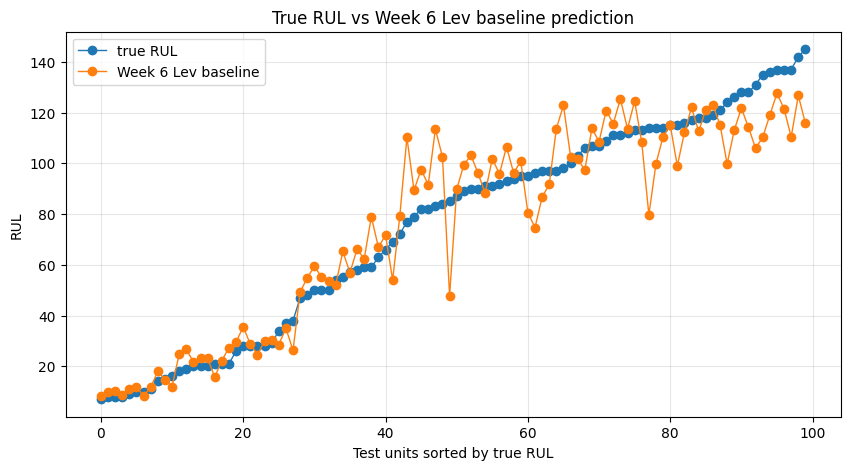

In [29]:
best_new_rows = official_results_df[official_results_df["method"] != "Week 6 Lev baseline"].sort_values(["MAE", "asymmetric_RUL_score"])
if len(best_new_rows):
    best_new_method = best_new_rows.iloc[0]["method"]
    best_new_prediction = official_predictions[best_new_method]
else:
    best_new_method = "Week 6 Lev baseline"
    best_new_prediction = pred_lev
order = np.argsort(np.asarray(y_test_official))

plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(pred_lev[order], label="Week 6 Lev baseline", marker="o", linewidth=1)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("True RUL vs Week 6 Lev baseline prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

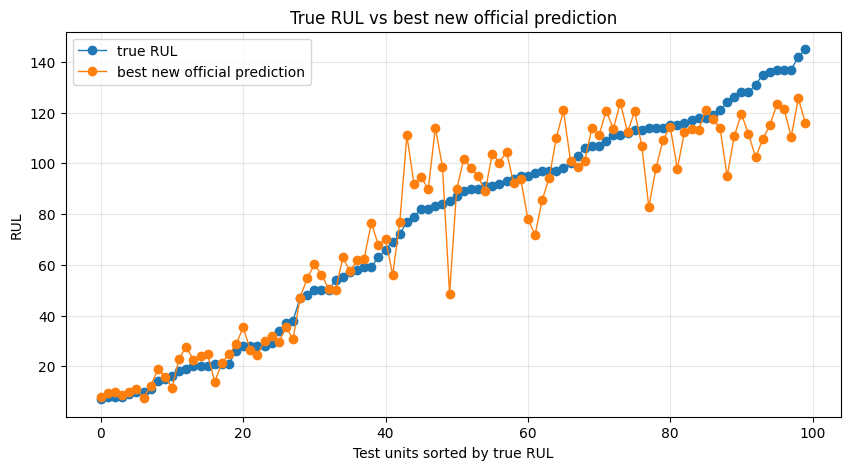

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(best_new_prediction[order], label="best new official prediction", marker="o", linewidth=1)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("True RUL vs best new official prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

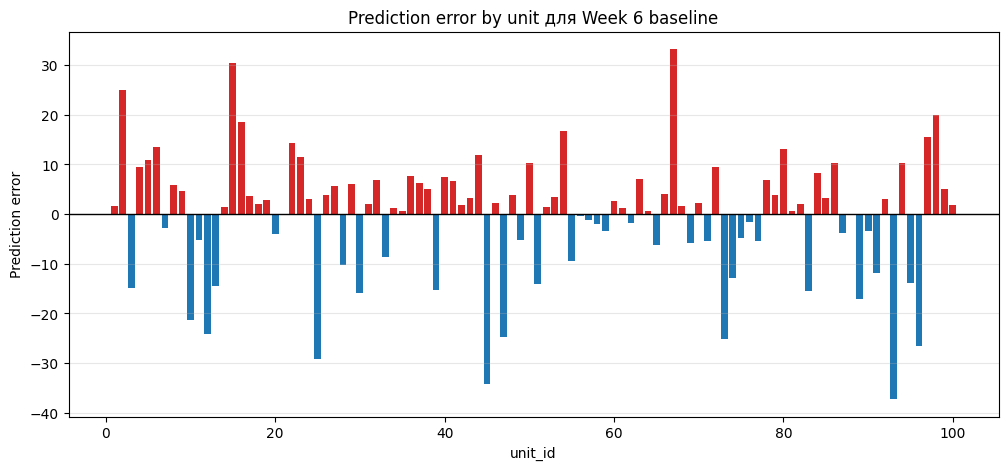

In [31]:
lev_error_df = build_error_table(y_test_official, pred_lev, "Week 6 Lev baseline", official_unit_ids)
plt.figure(figsize=(12, 5))
colors = np.where(lev_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(lev_error_df["id"], lev_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для Week 6 baseline")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

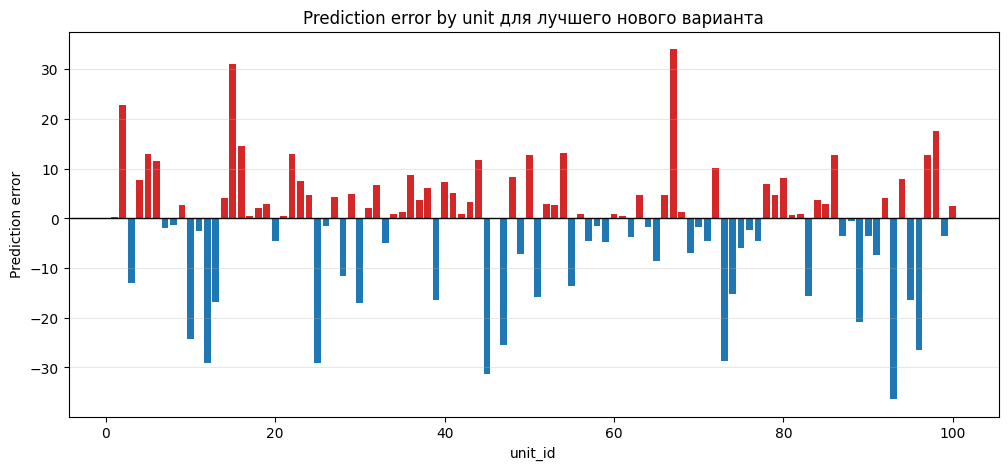

In [32]:
best_new_error_df = build_error_table(y_test_official, best_new_prediction, best_new_method, official_unit_ids)
plt.figure(figsize=(12, 5))
colors = np.where(best_new_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(best_new_error_df["id"], best_new_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для лучшего нового варианта")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

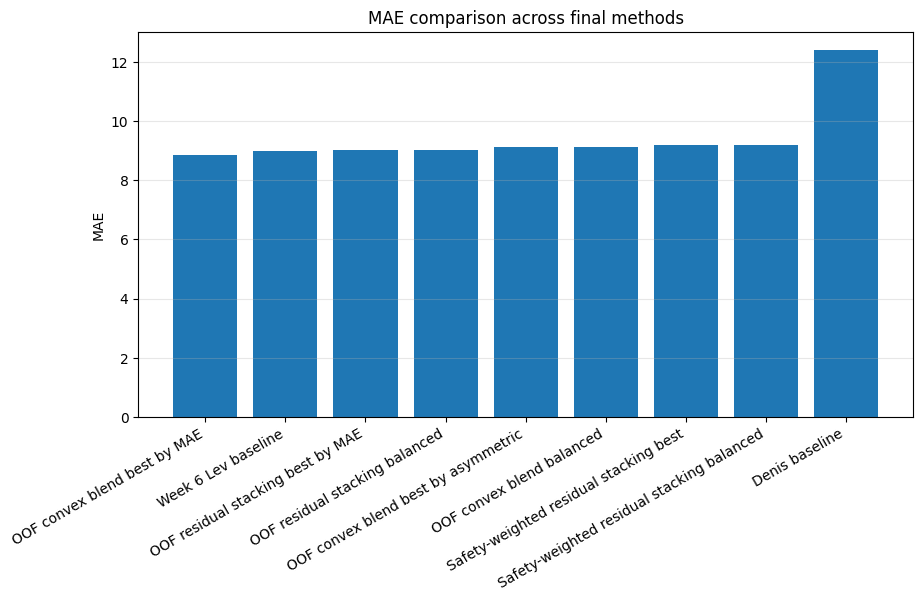

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(official_results_df["method"], official_results_df["MAE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("MAE")
plt.title("MAE comparison across final methods")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

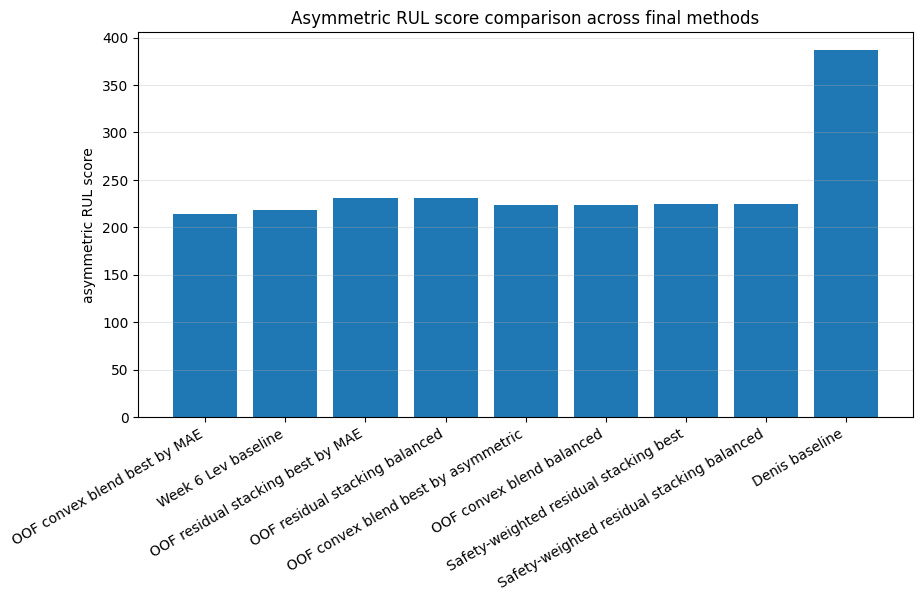

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(official_results_df["method"], official_results_df["asymmetric_RUL_score"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("asymmetric RUL score")
plt.title("Asymmetric RUL score comparison across final methods")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

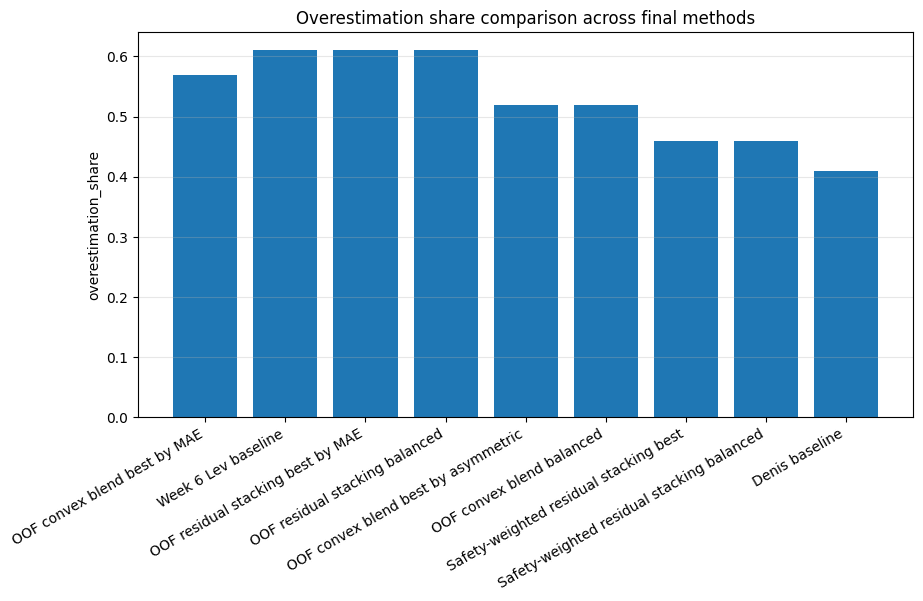

In [35]:
plt.figure(figsize=(10, 5))
plt.bar(official_results_df["method"], official_results_df["overestimation_share"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("overestimation_share")
plt.title("Overestimation share comparison across final methods")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

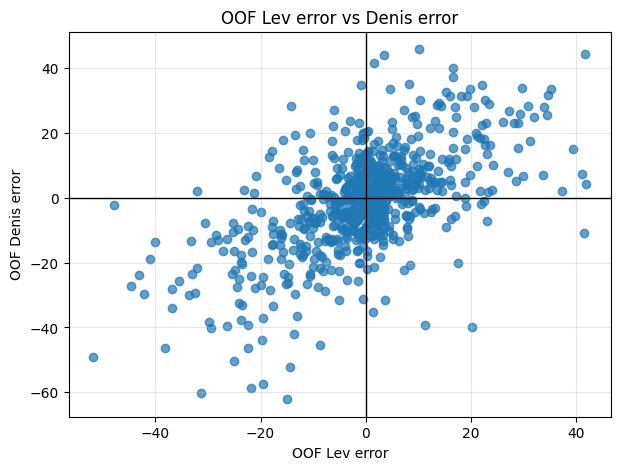

In [36]:
plt.figure(figsize=(7, 5))
plt.scatter(oof_meta_df["lev_error"], oof_meta_df["denis_error"], alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("OOF Lev error")
plt.ylabel("OOF Denis error")
plt.title("OOF Lev error vs Denis error")
plt.grid(True, alpha=0.3)
plt.show()

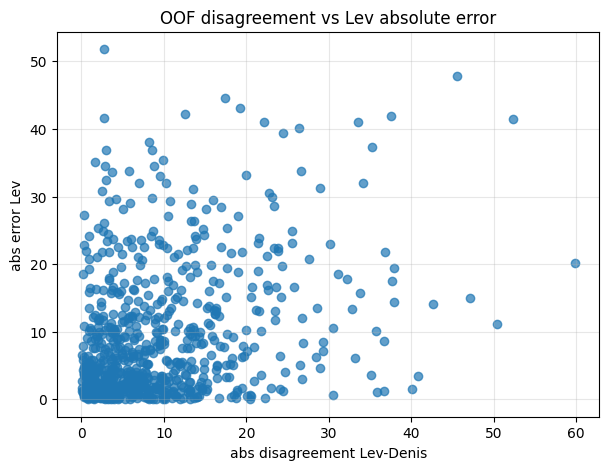

In [37]:
plt.figure(figsize=(7, 5))
plt.scatter(oof_meta_df["abs_disagreement_lev_denis"], oof_meta_df["lev_error"].abs(), alpha=0.7)
plt.xlabel("abs disagreement Lev-Denis")
plt.ylabel("abs error Lev")
plt.title("OOF disagreement vs Lev absolute error")
plt.grid(True, alpha=0.3)
plt.show()

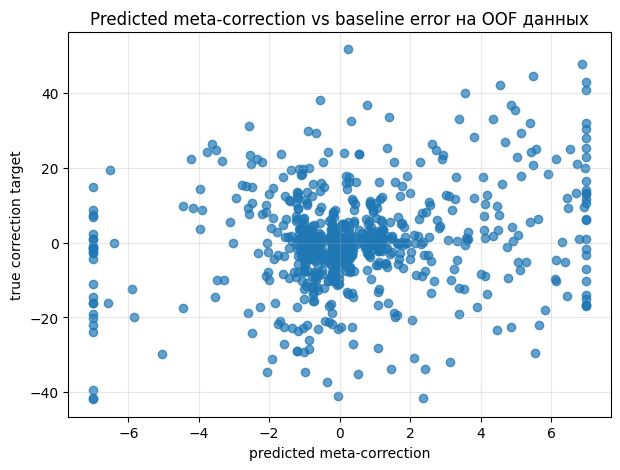

In [38]:
stacking_improved = bool((official_results_df[official_results_df["method"] != "Week 6 Lev baseline"]["MAE"] < week6_row["MAE"]).any() or (official_results_df[official_results_df["method"] != "Week 6 Lev baseline"]["asymmetric_RUL_score"] < week6_row["asymmetric_RUL_score"]).any())
if stacking_improved and residual_meta_correction_oof_plot is not None:
    plt.figure(figsize=(7, 5))
    plt.scatter(residual_meta_correction_oof_plot, -oof_meta_df["lev_error"], alpha=0.7)
    plt.xlabel("predicted meta-correction")
    plt.ylabel("true correction target")
    plt.title("Predicted meta-correction vs baseline error на OOF данных")
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Финальные выводы

In [39]:
convex_improved = bool((official_results_df[official_results_df["method"].str.contains("convex", case=False)]["MAE"] < week6_row["MAE"]).any())
residual_improved = bool((official_results_df[official_results_df["method"].str.contains("residual stacking", case=False)]["MAE"] < week6_row["MAE"]).any())
safety_weighted_improved_score = bool((official_results_df[official_results_df["method"].str.contains("Safety-weighted", case=False)]["asymmetric_RUL_score"] < week6_row["asymmetric_RUL_score"]).any())
any_improved = bool((official_results_df[official_results_df["method"] != "Week 6 Lev baseline"]["MAE"] < week6_row["MAE"]).any() or (official_results_df[official_results_df["method"] != "Week 6 Lev baseline"]["asymmetric_RUL_score"] < week6_row["asymmetric_RUL_score"]).any())

lines = []
if convex_improved:
    lines.append("Convex blending улучшил Week 6: прогноз Дениса содержит дополнительный полезный сигнал, и простое OOF-взвешивание разных представлений улучшило финальную точность.")
if residual_improved:
    lines.append("Residual stacking улучшил Week 6: meta-model научилась использовать расхождение между точной веткой Льва и health-oriented веткой Дениса для индивидуальной коррекции RUL.")
if safety_weighted_improved_score:
    lines.append("Safety-weighted stacking улучшил asymmetric RUL score: усиленный вес случаев завышения ресурса сделал итоговый прогноз безопаснее по асимметрической метрике.")
if not any_improved:
    lines.append("Разные ветки не дали устойчивого дополнительного сигнала, и Week 6 OOF residual correction остаётся лучшим вариантом.")
lines.append("Выбор параметров stacking проводился на OOF-прогнозах внутри train-выборки. Official test использовался только для финальной проверки выбранных вариантов. Это методологически аккуратнее дальнейшего ручного подбора формул по official test.")

display(Markdown("\n\n".join(lines)))

Convex blending улучшил Week 6: прогноз Дениса содержит дополнительный полезный сигнал, и простое OOF-взвешивание разных представлений улучшило финальную точность.

Выбор параметров stacking проводился на OOF-прогнозах внутри train-выборки. Official test использовался только для финальной проверки выбранных вариантов. Это методологически аккуратнее дальнейшего ручного подбора формул по official test.

## 15. Ограничения эксперимента

Notebook проверяет только OOF stacking уже найденных веток Lev и Denis. Новые cap, q, shift и top-candidates ensemble не подбираются на official test.